# 06 — Best Model Selection
**Proyek:** Klasifikasi Tingkat Risiko Stroke Berdasarkan Data Klinis dan Gaya Hidup Menggunakan Algoritma TabNet dengan Interpretasi Attention Mechanism

**Tahap:** Pemilihan & Penyimpanan Model Terbaik

**Tujuan:**
1. Memuat seluruh run MLflow dari eksperimen `stroke-risk-classification`.
2. Mengurutkan model berdasarkan **`val_roc_auc`** (metrik utama).
3. Menampilkan **leaderboard**, perbandingan visual, dan detail model terbaik.
4. Memuat ulang model terbaik dari MLflow registry & me-evaluasi pada test set.
5. Menyimpan ke `models/best_model.*` untuk inference selanjutnya.

## 1. Setup

In [1]:
import json
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
METRICS_DIR = PROJECT_ROOT / "metadata"

with open(PROJECT_ROOT / "params.yaml") as f:
    params = yaml.safe_load(f)
mlflow_cfg = params["mlflow"]
# Pakai sqlite backend yang sama dengan src/retrain.py & notebook 05
db_path = (PROJECT_ROOT / mlflow_cfg["tracking_db"]).resolve()
mlflow.set_tracking_uri(f"sqlite:///{db_path}")

PRIMARY = mlflow_cfg["primary_metric"]
print("Primary metric :", PRIMARY)
print("Tracking URI   :", mlflow.get_tracking_uri())

Primary metric : val_pr_auc
Tracking URI   : sqlite:////Users/macbookpro/Documents/Kuliah/Semester 6/Proyek Data Mining/Riset Data Mining/mlflow.db


## 2. Tarik Semua Run MLflow

In [2]:
client = mlflow.tracking.MlflowClient()
exp = client.get_experiment_by_name(mlflow_cfg["experiment_name"])
runs = client.search_runs(
    [exp.experiment_id],
    order_by=["attributes.start_time DESC"],
)

records = []
for r in runs:
    records.append({
        "run_name":      r.data.tags.get("mlflow.runName"),
        "family":        r.data.tags.get("model_family"),
        "stage":         r.data.tags.get("stage"),
        "start_time":    r.info.start_time,
        "val_pr_auc":    r.data.metrics.get("val_pr_auc"),
        "val_roc_auc":   r.data.metrics.get("val_roc_auc"),
        "val_f1":        r.data.metrics.get("val_f1"),
        "val_recall":    r.data.metrics.get("val_recall"),
        "val_precision": r.data.metrics.get("val_precision"),
        "test_pr_auc":   r.data.metrics.get("test_pr_auc"),
        "test_roc_auc":  r.data.metrics.get("test_roc_auc"),
        "test_f1":       r.data.metrics.get("test_f1"),
        "test_recall":   r.data.metrics.get("test_recall"),
        "test_precision":r.data.metrics.get("test_precision"),
        "test_threshold":r.data.metrics.get("test_threshold"),
        "run_id":        r.info.run_id,
    })

df_all = pd.DataFrame(records)
# Ambil run terbaru per run_name (yang sudah tuned & punya val_pr_auc)
df_tuned = df_all[df_all["val_pr_auc"].notna()].sort_values("start_time", ascending=False)
leaderboard = (df_tuned.groupby("run_name", as_index=False).first()
                       .sort_values(PRIMARY, ascending=False)
                       .reset_index(drop=True))
print(f"Total runs aktif: {len(leaderboard)}  (filter stage tuned, dedupe terbaru)\n")
display_cols = ["run_name", "family", "val_pr_auc", "val_roc_auc", "val_f1", "val_recall",
                "test_pr_auc", "test_roc_auc", "test_f1", "test_recall"]
leaderboard[display_cols].round(4)

Total runs aktif: 4  (filter stage tuned, dedupe terbaru)



,run_name,family,val_pr_auc,val_roc_auc,val_f1,val_recall,test_pr_auc,test_roc_auc,test_f1,test_recall
0,logreg,linear,0.2308,0.8642,0.3273,0.4865,0.1956,0.8185,0.3103,0.4865
1,tabnet,deep-tabular,0.2092,0.8585,0.3051,0.4865,0.2093,0.7840,0.2286,0.3243
2,xgboost,gradient-boosting,0.1573,0.8102,0.2435,0.3784,0.1245,0.7753,0.2017,0.3243
3,random_forest,tree-ensemble,0.1568,0.8365,0.2687,0.7297,0.1288,0.7870,0.2388,0.6486


## 3. Best Model

In [3]:
best = leaderboard.iloc[0]
print("BEST MODEL")
print("=" * 60)
print(f"Run name        : {best['run_name']}")
print(f"Model family    : {best['family']}")
print(f"Run ID          : {best['run_id']}")
print(f"Val ROC-AUC     : {best['val_roc_auc']:.4f}")
print(f"Val F1 / Recall : {best['val_f1']:.4f} / {best['val_recall']:.4f}")
print(f"Test ROC-AUC    : {best['test_roc_auc']:.4f}")
print(f"Test F1 / Recall: {best['test_f1']:.4f} / {best['test_recall']:.4f}")
print("=" * 60)

BEST MODEL
Run name        : logreg
Model family    : linear
Run ID          : b06ab963afc2420bb2737d71fccf585f
Val ROC-AUC     : 0.8642
Val F1 / Recall : 0.3273 / 0.4865
Test ROC-AUC    : 0.8185
Test F1 / Recall: 0.3103 / 0.4865


## 4. Visualisasi Perbandingan

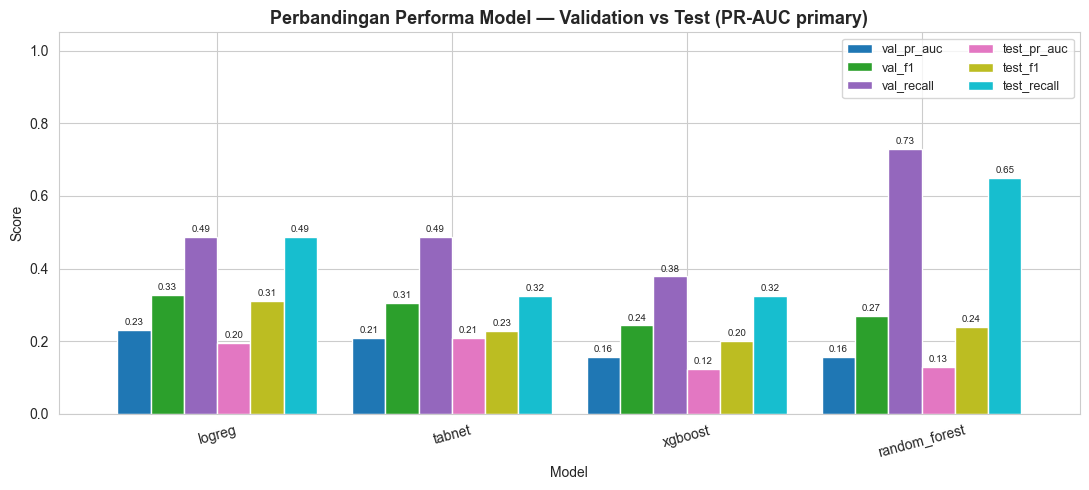

In [4]:
metric_cols = ["val_pr_auc", "val_f1", "val_recall", "test_pr_auc", "test_f1", "test_recall"]
plot_df = leaderboard.set_index("run_name")[metric_cols]

fig, ax = plt.subplots(figsize=(11, 5))
plot_df.plot(kind="bar", ax=ax, colormap="tab10", width=0.85, edgecolor="white")
ax.set_title("Perbandingan Performa Model — Validation vs Test (PR-AUC primary)", fontsize=13, fontweight="bold")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", ncol=2, fontsize=9)
ax.tick_params(axis="x", rotation=15)
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
fig.savefig(FIG_DIR / "model_comparison.png", dpi=130)
plt.show()

## 5. Highlight Best Model

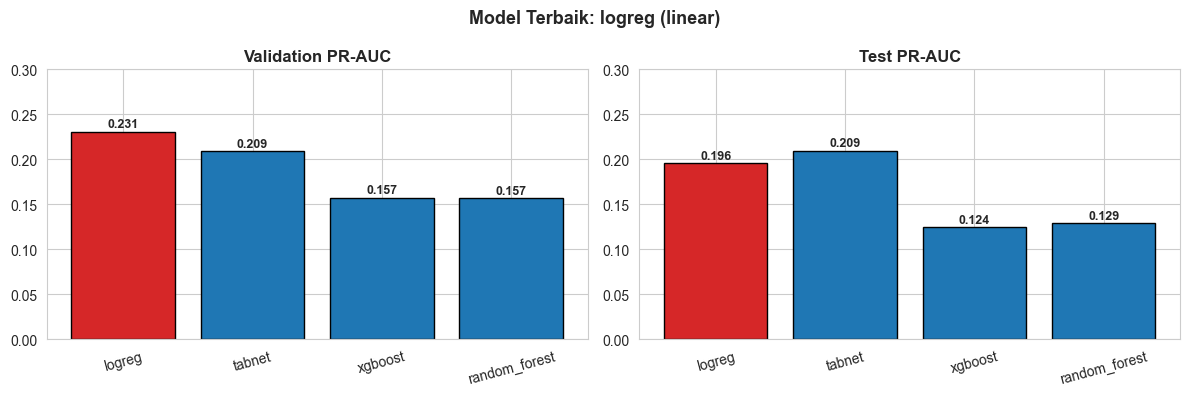

In [5]:
colors = ["#d62728" if rn == best["run_name"] else "#1f77b4" for rn in leaderboard["run_name"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ["val_pr_auc", "test_pr_auc"], ["Validation PR-AUC", "Test PR-AUC"]):
    bars = ax.bar(leaderboard["run_name"], leaderboard[metric], color=colors, edgecolor="black")
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(0.3, leaderboard[metric].max() * 1.2))
    ax.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, leaderboard[metric]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
fig.suptitle(f"Model Terbaik: {best['run_name']} ({best['family']})", fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(FIG_DIR / "best_model_highlight.png", dpi=130)
plt.show()

## 6. Muat Ulang Best Model & Verifikasi di Test Set

In [6]:
# Load best model dari folder lokal (sudah disimpan oleh src/retrain.py)
ready = np.load(DATA_PROCESSED / "tabnet_ready.npz")
X_test, y_test = ready["X_test"], ready["y_test"]

best_dir = MODELS_DIR / "best_model"
threshold = joblib.load(best_dir / "threshold.joblib")["threshold"]
print(f"Best model dir : {best_dir}")
print(f"Threshold      : {threshold:.4f}")

if best["family"] == "deep-tabular":
    from pytorch_tabnet.tab_model import TabNetClassifier
    loaded = TabNetClassifier()
    loaded.load_model(str(best_dir / "tabnet_model.zip"))
    proba = loaded.predict_proba(X_test.astype(np.float32))[:, 1]
elif best["family"] == "gradient-boosting":
    loaded = mlflow.xgboost.load_model(str(best_dir))
    proba = loaded.predict_proba(X_test)[:, 1]
else:
    loaded = mlflow.sklearn.load_model(str(best_dir))
    proba = loaded.predict_proba(X_test)[:, 1]

pred = (proba >= threshold).astype(int)

print(f"\nVerified Test ROC-AUC : {roc_auc_score(y_test, proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred, target_names=["No Stroke", "Stroke"], digits=4))

Best model dir : /Users/macbookpro/Documents/Kuliah/Semester 6/Proyek Data Mining/Riset Data Mining/models/best_model
Threshold      : 0.6056



Verified Test ROC-AUC : 0.8185

Classification Report:
              precision    recall  f1-score   support

   No Stroke     0.9724    0.9164    0.9436       730
      Stroke     0.2278    0.4865    0.3103        37

    accuracy                         0.8957       767
   macro avg     0.6001    0.7015    0.6270       767
weighted avg     0.9365    0.8957    0.9130       767



## 7. ROC Curve & Confusion Matrix Best Model

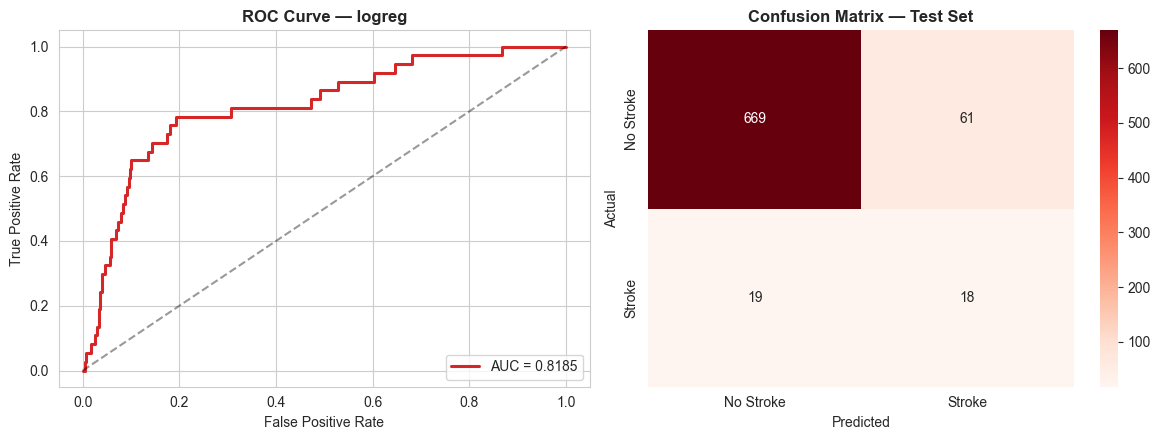

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[0].plot(fpr, tpr, lw=2.2, color="#d62728", label=f"AUC = {auc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC Curve — {best['run_name']}", fontweight="bold")
axes[0].legend(loc="lower right")

# Confusion matrix
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion Matrix — Test Set", fontweight="bold")

plt.tight_layout()
fig.savefig(FIG_DIR / "best_model_evaluation.png", dpi=130)
plt.show()

## 8. Simpan Best Model ke `models/`

In [8]:
# Read-only: best model sudah disimpan oleh src/retrain.py
# Notebook ini hanya menampilkan ringkasan metadata
best_meta_path = MODELS_DIR / "best_model.json"
with open(best_meta_path) as f:
    best_meta = json.load(f)

print("Best model metadata:", best_meta_path)
print(json.dumps(best_meta, indent=2, default=str))

Best model metadata: /Users/macbookpro/Documents/Kuliah/Semester 6/Proyek Data Mining/Riset Data Mining/models/best_model.json
{
  "run_id": "b06ab963afc2420bb2737d71fccf585f",
  "run_name": "logreg",
  "family": "linear",
  "primary_metric": "val_pr_auc",
  "threshold": 0.6056418695631336,
  "val_metrics": {
    "pr_auc": 0.23080114378488562,
    "roc_auc": 0.8642354683450574,
    "f1": 0.32727272727272727,
    "recall": 0.4864864864864865,
    "precision": 0.2465753424657534,
    "accuracy": 0.9035202086049544,
    "threshold": 0.6056418695631336
  },
  "test_metrics": {
    "pr_auc": 0.1955566972232307,
    "roc_auc": 0.8185486856719734,
    "f1": 0.3103448275862069,
    "recall": 0.4864864864864865,
    "precision": 0.22784810126582278,
    "accuracy": 0.8956975228161669,
    "threshold": 0.6056418695631336
  },
  "best_params": {
    "solver": "liblinear",
    "penalty": "l2",
    "class_weight": null,
    "C": 0.01610262027560939
  },
  "artifact_local_path": "models/best_model",

## 9. Register Model ke MLflow Model Registry (opsional)

In [9]:
# Registrasi ke MLflow Model Registry (opsional, manual)
# Di-skip otomatis saat dijalankan via DVC untuk menghindari duplikasi version.
import os
SKIP_REGISTRY = os.environ.get("DVC_STAGE") is not None or os.environ.get("SKIP_MLFLOW_REGISTRY") == "1"

if SKIP_REGISTRY:
    print("ℹ Registry dilewati (jalankan manual dari notebook untuk register).")
else:
    try:
        if best["family"] == "deep-tabular":
            print("ℹ TabNet tidak compatible dengan registry standar — skip.")
        else:
            model_uri = f"runs:/{best['run_id']}/model"
            registered = mlflow.register_model(model_uri, "stroke-risk-best-model")
            print(f"✓ Registered: {registered.name}  v{registered.version}")
    except Exception as e:
        print(f"Registry tidak aktif (lewati): {e}")

ℹ Registry dilewati (jalankan manual dari notebook untuk register).


## 10. Ringkasan Akhir

In [10]:
print("=" * 65)
print(" RINGKASAN AKHIR — STROKE RISK CLASSIFICATION")
print("=" * 65)
print(f" Best Model      : {best['run_name']:>20}  ({best['family']})")
print(f" Val   PR-AUC    : {best['val_pr_auc']:.4f}")
print(f" Val   ROC-AUC   : {best['val_roc_auc']:.4f}")
print(f" Test  PR-AUC    : {best['test_pr_auc']:.4f}")
print(f" Test  ROC-AUC   : {best['test_roc_auc']:.4f}")
print(f" Test  F1        : {best['test_f1']:.4f}")
print(f" Test  Recall    : {best['test_recall']:.4f}")
print(f" Test  Precision : {best['test_precision']:.4f}")
print(f" Threshold       : {threshold:.4f}")
print(f" Artifact path   : {best_dir}")
print(f" MLflow run id   : {best['run_id']}")
print("=" * 65)

 RINGKASAN AKHIR — STROKE RISK CLASSIFICATION
 Best Model      :               logreg  (linear)
 Val   PR-AUC    : 0.2308
 Val   ROC-AUC   : 0.8642
 Test  PR-AUC    : 0.1956
 Test  ROC-AUC   : 0.8185
 Test  F1        : 0.3103
 Test  Recall    : 0.4865
 Test  Precision : 0.2278
 Threshold       : 0.6056
 Artifact path   : /Users/macbookpro/Documents/Kuliah/Semester 6/Proyek Data Mining/Riset Data Mining/models/best_model
 MLflow run id   : b06ab963afc2420bb2737d71fccf585f
